# Block 1 - Commodity Futures Portfolios
## Basis, Momentum, Hedging Pressure & Value Tercile Sorts
## Data source: Refinitiv Datastream via WRDS (`trsamp_dsfut`)

---

### What this notebook does

Constructs **Block 1** of the test asset universe (Table 1, N=78): 12 commodity futures
portfolios formed by monthly tercile sorts of 27 liquid futures contracts on four
commodity-specific characteristics. Returns are **weekly Wednesday-to-Wednesday
excess returns** matching the convention in Blocks 2-4.

Futures price data comes from **Refinitiv Datastream via WRDS** (`trsamp_dsfut.dsfut`),
the same data infrastructure used for Blocks 2-3. Front-month and second-nearby
continuous series are identified via `trsamp_dsfut.wrds_contract_info`.

| Step | Description |
|------|-------------|
| **1** | Configuration & 27-contract universe |
| **2** | Connect to WRDS and identify Datastream contract codes |
| **3** | Pull daily futures prices (front + second nearby) |
| **4** | Compute weekly excess returns |
| **5** | Compute sort characteristics (Basis, Momentum, Value) |
| **6** | Load CFTC COT data for Hedging Pressure |
| **7** | Assign monthly tercile ranks |
| **8** | Build equal-weighted tercile portfolios |
| **9** | Construct Pass 3 observable factors |
| **10** | Diagnostics |
| **11** | Save outputs |

### Block 1 sort schemes (27-contract universe)

| # | Sort | N | Factor | Period |
|---|------|---|--------|--------|
| 1 | Basis terciles | 3 | rBasis = B1 - B3 | 1990-2023 |
| 2 | Momentum terciles | 3 | rMOM = M3 - M1 | 1990-2023 |
| 3 | Hedging Pressure terciles | 3 | rHP = HP3 - HP1 | 1995-2023 |
| 4 | Value terciles | 3 | rValue = V3 - V1 | 1995-2023 |
| **Total** | | **12** | | |

### Outputs
- `commodity_futures_weekly.csv`  - 12 tercile portfolio weekly excess returns
- `commodity_factors_weekly.csv`  - 4 long-short observable factors (Pass 3)
- `futures_sort_counts.csv`       - contract counts per portfolio per month


## Configuration

In [ ]:
import wrds
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
import warnings
import matplotlib.pyplot as plt
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)

# User settings
WRDS_USER    = 'fdxavierj5'
START_DATE   = '1989-01-01'   # need 12 months pre-sample for momentum
END_DATE     = '2023-12-31'
SAMPLE_START = '1990-01-01'   # first date in output (basis + momentum ready)
HP_START     = '1995-01-01'   # CFTC COT starts March 1995

# 27 liquid commodity futures - Refinitiv Datastream mnemonics
# Each contract needs:
#   F1_code : Datastream mnemonic for the continuous FRONT-month series
#   F2_code : Datastream mnemonic for the continuous SECOND-nearby series
# These are the standard Datastream continuation codes available via
# trsamp_dsfut.wrds_contract_info (comtype = 'CFUT' or 'FUT').

CONTRACT_MAP = {
    # Name                  F1 mnemonic   F2 mnemonic   CFTC COT market name
    'WTI Crude Oil'     : ('NYMCL',       'NYMCLB',      'CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE EXCHANGE'),
    'Brent Crude Oil'   : ('LCOA',        'LCOAB',       'BRENT CRUDE OIL - NEW YORK MERCANTILE EXCHANGE'),
    'Natural Gas'       : ('NYMNG',       'NYMNGB',      'NATURAL GAS - NEW YORK MERCANTILE EXCHANGE'),
    'Heating Oil'       : ('NYMHO',       'NYMHOB',      'NO. 2 HEATING OIL - NEW YORK HARBOR'),
    'Gasoline RBOB'     : ('NYMRB',       'NYMRBB',      'GASOLINE BLENDSTOCK (RBOB) - NEW YORK HARBOR'),
    'Gas Oil'           : ('LGOIL',       'LGOILB',      'GAS OIL - ICE FUTURES EUROPE'),
    'Gold'              : ('NYMGC',       'NYMGCB',      'GOLD - COMMODITY EXCHANGE INC.'),
    'Silver'            : ('NYMSI',       'NYMSIB',      'SILVER - COMMODITY EXCHANGE INC.'),
    'Copper'            : ('NYMHG',       'NYMHGB',      'COPPER-GRADE #1 - COMMODITY EXCHANGE INC.'),
    'Platinum'          : ('NYMPL',       'NYMPLB',      'PLATINUM - NEW YORK MERCANTILE EXCHANGE'),
    'Palladium'         : ('NYMPA',       'NYMPAB',      'PALLADIUM - NEW YORK MERCANTILE EXCHANGE'),
    'Aluminium'         : ('LMAHD',       'LMAHDB',      'ALUMINUM - COMMODITY EXCHANGE INC.'),
    'Corn'              : ('CBTCO',       'CBTCOB',      'CORN - CHICAGO BOARD OF TRADE'),
    'Soybeans'          : ('CBTSB',       'CBTSBSB',     'SOYBEANS - CHICAGO BOARD OF TRADE'),
    'Soybean Meal'      : ('CBTSM',       'CBTSMB',      'SOYBEAN MEAL - CHICAGO BOARD OF TRADE'),
    'Soybean Oil'       : ('CBTBO',       'CBTBOB',      'SOYBEAN OIL - CHICAGO BOARD OF TRADE'),
    'Wheat CBOT'        : ('CBTWT',       'CBTWTB',      'WHEAT - CHICAGO BOARD OF TRADE'),
    'Wheat KC'          : ('KCWT',        'KCWTB',       'WHEAT - KANSAS CITY BOARD OF TRADE'),
    'Cotton'            : ('NYCTN',       'NYCTNB',      'COTTON NO. 2 - NEW YORK BOARD OF TRADE'),
    'Oats'              : ('CBTOAT',      'CBTOATB',     'OATS - CHICAGO BOARD OF TRADE'),
    'Live Cattle'       : ('CMXLC',       'CMXLCB',      'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE'),
    'Lean Hogs'         : ('CMXLH',       'CMXLHB',      'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE'),
    'Feeder Cattle'     : ('CMXFC',       'CMXFCB',      'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE'),
    'Sugar No11'        : ('NYSB',        'NYSBB',       'SUGAR NO. 11 (WORLD) - NEW YORK BOARD OF TRADE'),
    'Coffee'            : ('NYKC',        'NYKCB',       'COFFEE C - NEW YORK BOARD OF TRADE'),
    'Cocoa'             : ('NYCC',        'NYCCB',       'COCOA - NEW YORK BOARD OF TRADE'),
    'Lumber'            : ('CMXLBR',      'CMXLBRB',     'RANDOM LENGTH LUMBER - CHICAGO MERCANTILE EXCHANGE'),
}

CONTRACT_NAMES = list(CONTRACT_MAP.keys())
print("Configuration set.")
print(f"  WRDS user      : {WRDS_USER}")
print(f"  Sample         : {START_DATE} --> {END_DATE}")
print(f"  Output period  : {SAMPLE_START} --> {END_DATE}")
print(f"  HP period      : {HP_START} --> {END_DATE}")
print(f"  Contracts      : {len(CONTRACT_MAP)}")
print(f"  Block 1 target : 4 sorts x 3 terciles = 12 portfolios")

Configuration set.
  WRDS user      : fdxavierj5
  Sample         : 1989-01-01 → 2023-12-31
  Output period  : 1990-01-01 → 2023-12-31
  HP period      : 1995-01-01 → 2023-12-31
  Contracts      : 27
  Block 1 target : 4 sorts × 3 terciles = 12 portfolios


## Connect to WRDS and Verify Datastream Contract Codes

Futures price data is in the Refinitiv Datastream futures tables on WRDS:
- `trsamp_dsfut.dsfut`            - daily prices per contract
- `trsamp_dsfut.wrds_contract_info` - contract metadata / mnemonic lookup

In [31]:
db = wrds.Connection(wrds_username=WRDS_USER)
print("Connected to WRDS.")

Loading library list...
Done
Connected to WRDS.


In [ ]:
import pandas as pd
import numpy as np
import os
import urllib.request, zipfile, io
import warnings
warnings.filterwarnings('ignore')

FUTURES_FILE = 'commodity_futures_data.xlsx'
START_DATE   = '1989-01-01'
END_DATE     = '2023-12-31'
SAMPLE_START = '1990-01-01'
HP_START     = '1995-01-01'
OUT_DIR      = r'Output/'

# Format: 'Name': ('F1_code', 'F2_code', 'Sector')
CONTRACT_MAP = {
    'WTI Crude Oil'  : ('NCLC.01', 'NCLC.02', 'Energy'),
    'Brent Crude Oil': ('LLCC.01', 'LLCC.02', 'Energy'),
    'Natural Gas'    : ('NNGC.01', 'NNGC.02', 'Energy'),
    'Heating Oil'    : ('NHOC.01', 'NHOC.02', 'Energy'),
    'Gasoline RBOB'  : ('NRBC.01', 'NRBC.02', 'Energy'),
    'Gas Oil'        : ('LLEC.01', 'LLEC.02', 'Energy'),
    'Gold'           : ('NGCC.01', 'NGCC.02', 'Metals'),
    'Silver'         : ('NSLC.01', 'NSLC.02', 'Metals'),
    'Copper'         : ('NHGC.01', 'NHGC.02', 'Metals'),
    'Platinum'       : ('NPLC.01', 'NPLC.02', 'Metals'),
    'Palladium'      : ('NPAC.01', 'NPAC.02', 'Metals'),
    'Aluminium'      : ('LAHC.01', 'LAHC.02', 'Metals'),
    'Corn'           : ('CCFC.01', 'CCFC.02', 'Grains'),
    'Wheat CBOT'     : ('CWFC.01', 'CWFC.02', 'Grains'),
    'Wheat KC'       : ('KKKC.01', 'KKKC.02', 'Grains'),
    'Soybeans'       : ('CSYC.01', 'CSYC.02', 'Grains'),
    'Soybean Oil'    : ('CZLCS01', 'CZLCS02', 'Grains'),
    'Soybean Meal'   : ('CZMCS01', 'CZMCS02', 'Grains'),
    'Cotton'         : ('NCTC.01', 'NCTC.02', 'Softs'),
    'Sugar No11'     : ('NSBC.01', 'NSBC.02', 'Softs'),
    'Coffee'         : ('NKCC.01', 'NKCC.02', 'Softs'),
    'Cocoa'          : ('NCCC.01', 'NCCC.02', 'Softs'),
    'Live Cattle'    : ('CLDC.01', 'CLDC.02', 'Livestock'),
    'Lean Hogs'      : ('CLGC.01', 'CLGC.02', 'Livestock'),
    'Feeder Cattle'  : ('CFDC.01', 'CFDC.02', 'Livestock'),
    'Lumber'         : ('CLBC.01', 'CLBC.02', 'Softs'),
    'Nickel'         : ('LNIC.01', 'LNIC.02', 'Metals'),  # replaces Oats
}
CONTRACT_NAMES = list(CONTRACT_MAP.keys())

print(f"Contracts: {len(CONTRACT_MAP)}")
for sector in ['Energy','Metals','Grains','Softs','Livestock']:
    n = sum(1 for v in CONTRACT_MAP.values() if v[2] == sector)
    print(f"  {sector}: {n}")

Contracts: 27
  Energy: 6
  Metals: 7
  Grains: 6
  Softs: 5
  Livestock: 3


## Pull Daily Futures Prices from Refinitiv Datastream

Pull the `pi` (settlement price) field from `trsamp_dsfut.dsfut` for:
- **F1**: front-month continuous series (mnemonic ending in no suffix)
- **F2**: second-nearby continuous series (mnemonic ending in 'B')

Settlement prices are used rather than mid-quotes to avoid bid-ask bounce
and are the standard in commodity futures return studies.

In [ ]:
# ── Cell 3: Load F1/F2 prices from commodity_futures_data.xlsx ───────────────
# Identical loading pattern to commodity_equity_portfolios_by_characteristics.ipynb
# Datastream format: row 4 = Code row with 'NCLC.01(PS)', 'NCLC.01(OI)', etc.
# Filter to PS columns only, skip OI.

meta     = pd.read_excel(FUTURES_FILE, header=None, nrows=6, dtype=str)
code_row = meta.iloc[4, :]

ps_positions, ps_codes = [], []
for pos, val in code_row.items():
    s = str(val) if pd.notna(val) else ''
    if '(PS)' in s:
        ps_positions.append(pos)
        ps_codes.append(s.replace('(PS)', '').strip())

print(f"PS series found: {len(ps_codes)}")

raw = pd.read_excel(FUTURES_FILE, header=None, skiprows=6,
                    usecols=[0] + ps_positions, index_col=0)
raw.index      = pd.to_datetime(raw.index, errors='coerce')
raw.index.name = 'date'
raw.columns    = ps_codes
raw = raw.loc[raw.index.notna()].sort_index().apply(pd.to_numeric, errors='coerce')
raw = raw.loc[START_DATE:END_DATE]

print(f"Loaded: {raw.shape[0]:,} daily obs x {raw.shape[1]} PS series")
print(f"Period: {raw.index.min().date()} - {raw.index.max().date()}")

# Split into F1 / F2 using CONTRACT_MAP
F1 = pd.DataFrame(index=raw.index)
F2 = pd.DataFrame(index=raw.index)

for name, (f1c, f2c, _) in CONTRACT_MAP.items():
    F1[name] = raw[f1c] if f1c in raw.columns else np.nan
    F2[name] = raw[f2c] if f2c in raw.columns else np.nan

missing = [n for n in CONTRACT_MAP if F1[n].isna().all()]
if missing:
    print(f"WARNING - all-NaN F1 series: {missing}")

print(f"\nF1: {F1.shape}  |  F2: {F2.shape}")
print(f"F1 coverage:\n{F1.notna().mean().round(2).sort_values().to_string()}")

PS series found: 61
Loaded: 9,130 daily obs × 61 PS series
Period: 1989-01-02 – 2023-12-29

F1: (9130, 27)  |  F2: (9130, 27)
F1 coverage:
Soybean Meal      0.5100
Soybean Oil       0.5100
Gasoline RBOB     0.5200
Aluminium         0.8700
Nickel            0.8700
Natural Gas       0.9600
Lumber            0.9800
Brent Crude Oil   1.0000
Silver            1.0000
Copper            1.0000
Platinum          1.0000
Palladium         1.0000
Heating Oil       1.0000
Gas Oil           1.0000
Gold              1.0000
WTI Crude Oil     1.0000
Soybeans          1.0000
Wheat KC          1.0000
Wheat CBOT        1.0000
Corn              1.0000
Coffee            1.0000
Cocoa             1.0000
Cotton            1.0000
Sugar No11        1.0000
Lean Hogs         1.0000
Live Cattle       1.0000
Feeder Cattle     1.0000


## Compute Weekly Futures Excess Returns

The excess return on a fully collateralised long futures position is the
**log price change** of the front-month contract:

$$r_{i,t} = \ln(F1_{i,t} / F1_{i,t-1})$$

Returns are compounded to **Wednesday-to-Wednesday** weekly frequency
and excess returns are computed by subtracting the weekly Fama-French RF.
This exactly mirrors the convention in Blocks 2-3.

In [ ]:
# ── Cell 3: Fix known data errors ────────────────────────────────────────────

# Heating Oil: two observations recorded at ~75x surrounding prices (unit error)
F1.loc['2009-10-06':'2009-10-07', 'Heating Oil'] = np.nan
F2.loc['2009-10-06':'2009-10-07', 'Heating Oil'] = np.nan
print("Fixed: Heating Oil 2009-10-06/07 --> NaN")

# General isolated spike detector: flag any daily price that is >5x or <0.2x
# both its previous and next observation (single-day error, not a trend)
print("\nChecking for remaining isolated spikes...")
for name in CONTRACT_MAP:
    for df, label in [(F1, 'F1'), (F2, 'F2')]:
        if name not in df.columns:
            continue
        s = df[name].dropna()
        ratio_prev = s / s.shift(1)
        ratio_next = s / s.shift(-1)
        spike = ((ratio_prev > 5)  & (ratio_next > 5)) | \
                ((ratio_prev < 0.2) & (ratio_next < 0.2))
        # Exclude 2020-04-20 WTI negative price - real market event
        spike = spike & ~(spike.index.isin(
            [pd.Timestamp('2020-04-20')] if name == 'WTI Crude Oil' else []))
        if spike.any():
            print(f"  {label} {name}: {spike.sum()} spike(s) --> NaN")
            df.loc[spike[spike].index, name] = np.nan

print("Done.")

Fixed: Heating Oil 2009-10-06/07 → NaN

Checking for remaining isolated spikes...
Done.


In [ ]:
# Futures excess return including roll yield
#
# Proper futures excess return = spot return + roll yield
# Roll yield ≈ (F1 - F2) / F2  (the convergence premium for backwardated markets)
#
# We use the Gorton-Rouwenhorst (2006) approximation:
#   r_t = (F1_t / F1_{t-1}) - 1   when holding the same contract

def compound_returns(series):
    valid = series.dropna()
    if len(valid) == 0:
        return np.nan
    return (1 + valid).prod() - 1

#RF
print("Downloading Fama-French daily RF...")
rf_url   = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
            "ftp/F-F_Research_Data_Factors_daily_CSV.zip")
response = urllib.request.urlopen(rf_url)
zf       = zipfile.ZipFile(io.BytesIO(response.read()))
fname    = zf.namelist()[0]
ff_daily = pd.read_csv(zf.open(fname), skiprows=4, index_col=0)
valid_idx = ff_daily.index.astype(str).str.match(r'^\d{8}$')
ff_daily  = ff_daily[valid_idx].copy()
ff_daily.index = pd.to_datetime(ff_daily.index.astype(str), format='%Y%m%d')
ff_daily['RF'] = ff_daily['RF'].astype(float) / 100
rf_weekly = (ff_daily['RF']
             .resample('W-WED')
             .apply(compound_returns)
             .rename('rf'))

# Roll-adjusted weekly return
# For each week:
#   price_return = F1_end / F1_start - 1  (within-week, no roll)
#   roll_yield   = (F1_start - F2_start) / F2_start  scaled to 1 week
#                = basis_daily * (days_in_week / days_in_month)
#
# Basis daily: (F1 - F2) / F2 at each day
# Roll yield accrues daily: we add it to the daily price return before compounding

basis_daily  = (F1 - F2) / F2          # positive = backwardation
roll_daily   = basis_daily / 21        # approx 21 trading days per month

# Total daily futures return = price change + roll yield accrual
daily_price  = F1.pct_change()
daily_total  = daily_price.add(roll_daily, fill_value=0)

# Weekly aggregation with roll-week filter on price return only
weekly_ret = pd.DataFrame(dtype=float)

for name in CONTRACT_MAP:
    if name not in F1.columns:
        continue
    prices  = F1[name]
    d_total = daily_total[name]

    def weekly_vw(group):
        valid = group.dropna()
        if len(valid) < 3:
            return np.nan
        p_start = prices.loc[valid.index[0]]
        p_end   = prices.loc[valid.index[-1]]
        if pd.isna(p_start) or pd.isna(p_end) or p_start <= 0 or p_end <= 0:
            return np.nan
        if not (0.5 <= p_end / p_start <= 2.0):
            return np.nan
        return compound_returns(valid)

    weekly_ret[name] = d_total.resample('W-WED').apply(weekly_vw)

# Subtract RF
weekly_excess = (weekly_ret
                 .subtract(rf_weekly, axis=0)
                 .loc[SAMPLE_START:END_DATE]
                 .dropna(how='all'))

print(f"RF: {rf_weekly.mean()*52*100:.2f}% p.a.")
print(f"\nWeekly excess returns (with roll yield):")
print(f"  Shape : {weekly_excess.shape[0]:,} weeks x {weekly_excess.shape[1]} contracts")
print(f"\nAnnualised mean returns (%):")
print((weekly_excess.mean() * 52 * 100).round(2).sort_values().to_string())

RF: 3.13% p.a.

Weekly excess returns (with roll yield):
  Shape : 1,774 weeks × 27 contracts

Annualised mean returns (%):
Wheat CBOT        -19.2100
Corn              -14.2300
Lean Hogs         -12.5700
Coffee            -11.3700
Wheat KC           -8.8700
Natural Gas        -8.6900
Cocoa              -5.8900
Cotton             -5.7100
Lumber             -5.2600
Aluminium          -2.9700
Sugar No11          0.1000
Live Cattle         1.5100
Feeder Cattle       1.6900
Platinum            1.8200
Gold                1.8900
Soybeans            3.4600
Silver              4.2100
Soybean Oil         5.5700
WTI Crude Oil       7.0300
Copper              7.0500
Heating Oil         7.5300
Nickel              7.7900
Brent Crude Oil    10.2800
Gas Oil            10.9400
Gasoline RBOB      12.0300
Soybean Meal       12.1300
Palladium          24.4900


## Compute Sort Characteristics (Basis, Momentum, Value)

All three price-based characteristics are computed at **monthly frequency**
(last Wednesday of each month) directly from the Refinitiv Datastream prices.

| Characteristic | Definition |
|----------------|------------|
| **Basis** | $(F2_t - F1_t) / F1_t$ - second-nearby minus front-month spread |
| **Momentum** | 12m cumulative return, skip 1 month (12m-1m) |
| **Value** | $\log[\overline{F1}_{t-4.5yr,t-5.5yr} / F1_t]$ |

Basis < 0 means backwardation (F1 > F2 --> positive roll yield --> B1 tercile).  
Hedging Pressure is added in Section 6 from CFTC COT data.

In [ ]:
# BASIS: (F2 - F1) / F1 at month-end Wednesday
# Using Wednesday-close prices for consistency with weekly return convention
f1_me = F1.resample('ME').last()
f2_me = F2.resample('ME').last()

basis_monthly = (f2_me - f1_me) / f1_me
print(f"Basis: {basis_monthly.shape}")
print(basis_monthly.mean().round(4).sort_values().to_string())

Basis: (420, 27)
Gasoline RBOB     -0.0046
Heating Oil       -0.0030
Gas Oil           -0.0026
Brent Crude Oil   -0.0025
Live Cattle       -0.0017
Copper            -0.0009
Soybean Oil        0.0000
Soybean Meal       0.0000
Palladium          0.0004
Soybeans           0.0005
Nickel             0.0006
Feeder Cattle      0.0011
WTI Crude Oil      0.0012
Platinum           0.0019
Gold               0.0024
Silver             0.0028
Aluminium          0.0040
Sugar No11         0.0073
Cotton             0.0084
Cocoa              0.0096
Wheat KC           0.0103
Coffee             0.0152
Corn               0.0159
Lumber             0.0159
Wheat CBOT         0.0201
Natural Gas        0.0203
Lean Hogs          0.0222


In [ ]:
# MOMENTUM: 12m-1m cumulative log return on F1
# Matches equity script: shift(1) skips most recent month, rolling(12) sums prior 12
f1_log_ret = np.log(f1_me / f1_me.shift(1))
mom_monthly = np.expm1(
    f1_log_ret.shift(1).rolling(12, min_periods=10).sum()
)
print(f"\nMomentum: {mom_monthly.shape}")
print(mom_monthly.mean().round(4).sort_values().to_string())


Momentum: (420, 27)
Live Cattle       0.0325
Feeder Cattle     0.0406
Platinum          0.0414
Wheat CBOT        0.0463
Soybeans          0.0470
Lean Hogs         0.0472
Aluminium         0.0476
Cotton            0.0493
Wheat KC          0.0539
Cocoa             0.0564
Gold              0.0589
Corn              0.0607
Copper            0.0737
Sugar No11        0.0749
Silver            0.0753
Coffee            0.0779
Lumber            0.0786
Soybean Meal      0.0818
Gasoline RBOB     0.0870
Soybean Oil       0.0978
WTI Crude Oil     0.1012
Natural Gas       0.1061
Brent Crude Oil   0.1075
Gas Oil           0.1151
Heating Oil       0.1152
Nickel            0.1290
Palladium         0.1404


In [ ]:
# VALUE: log[avg(F1, t-4.5yr to t-5.5yr) / F1_t]
# Window: 54 months ago to 66 months ago (centred on 5 years back)
# Rolling mean of F1 over that historical window, then log ratio to current
f1_hist_avg = f1_me.shift(54).rolling(12, min_periods=6).mean()
value_monthly = np.log(f1_hist_avg / f1_me)

print(f"\nValue: {value_monthly.shape}")
print(value_monthly.mean().round(4).sort_values().to_string())


Value: (420, 27)
Palladium         -0.4564
Gold              -0.2550
Silver            -0.2516
Heating Oil       -0.2053
Brent Crude Oil   -0.1989
Gas Oil           -0.1982
Copper            -0.1878
Nickel            -0.1795
WTI Crude Oil     -0.1750
Lumber            -0.1401
Cocoa             -0.1398
Platinum          -0.1326
Soybean Meal      -0.1140
Corn              -0.1126
Soybeans          -0.1101
Feeder Cattle     -0.1061
Wheat CBOT        -0.0984
Wheat KC          -0.0978
Coffee            -0.0915
Live Cattle       -0.0883
Natural Gas       -0.0833
Soybean Oil       -0.0745
Lean Hogs         -0.0726
Sugar No11        -0.0658
Aluminium         -0.0633
Cotton            -0.0281
Gasoline RBOB      0.0165


## Hedging Pressure

The Hedging Pressure characteristic is computed from the CFTC Commitments of
Traders (COT) Legacy Combined reports, the same source already used in
Block 2 for the HP-proxy. The two-source splice approach (Legacy Futures-Only
1995-2009, Disaggregated PMPU 2009-2023) from Block 2 is reused here.

$$HP_{i,t} = \frac{Short^{comm}_{i,t} - Long^{comm}_{i,t}}{Short^{comm}_{i,t} + Long^{comm}_{i,t}}$$

COT reports are released on Fridays with Tuesday data; a 1-period monthly lag
is applied to avoid look-ahead bias.

In [ ]:
# Hedging Pressure - CFTC COT two-source splice
# Direct port of commodity_equity_portfolios_by_characteristics.ipynb cells 19-20.
# Only change: COT_CONTRACT_MAP expanded from 13 to 27 contracts.

import requests, time, os
import numpy as np
import pandas as pd

SPLICE_DATE = '2009-06-01'

SOURCES = {
    'legacy': dict(
        endpoint   = 'https://publicreporting.cftc.gov/resource/rh2e-ybqs.json',
        local_csv  = 'cot_legacy_futonly.csv',
        date_col   = 'report_date_as_yyyy_mm_dd',
        name_col   = 'contract_market_name',
        long_col   = 'comm_positions_long_all',
        short_col  = 'comm_positions_short_all',
        date_start = '1995-01-01',
        date_end   = '2009-05-31',
        label      = 'Legacy FutOnly',
    ),
    'disagg': dict(
        endpoint   = 'https://publicreporting.cftc.gov/resource/72hh-3qpy.json',
        local_csv  = 'cot_disagg_futonly.csv',
        date_col   = 'report_date_as_yyyy_mm_dd',
        name_col   = 'contract_market_name',
        long_col   = 'prod_merc_positions_long_all',
        short_col  = 'prod_merc_positions_short_all',
        date_start = '2009-06-01',
        date_end   = '2023-12-31',
        label      = 'Disaggregated FutOnly (PMPU)',
    ),
}

FILTER_KEYWORDS = [
    'CRUDE', 'WTI', 'BRENT',
    'NATURAL GAS', 'NAT GAS', 'HEATING OIL', 'ULSD', 'GASOLINE', 'GASOIL',
    'GOLD', 'SILVER', 'COPPER', 'PLATINUM', 'PALLADIUM', 'ALUMINUM',
    'SOYBEAN', 'CORN', 'WHEAT',
    'COTTON', 'SUGAR', 'COFFEE', 'COCOA',
    'CATTLE', 'HOGS', 'FEEDER',
    'LUMBER',
]

def _load_cot_source(cfg):
    if cfg['local_csv']:
        print(f"  {cfg['label']}: loading from {cfg['local_csv']}...")
        header = pd.read_csv(cfg['local_csv'], nrows=0)
        lc_map = {c.lower().replace(' ', '_'): c for c in header.columns}
        def find_col(key):
            return lc_map.get(key, lc_map.get(key.lower(), None))
        actual = {
            'date' : find_col(cfg['date_col']),
            'name' : find_col(cfg['name_col']),
            'long' : find_col(cfg['long_col']),
            'short': find_col(cfg['short_col']),
        }
        missing = {k: v for k, v in actual.items() if v is None}
        if missing:
            raise ValueError(
                f"{cfg['label']}: could not find columns {list(missing.keys())}.\n"
                f"Available: {header.columns.tolist()}"
            )
        chunks = []
        for chunk in pd.read_csv(cfg['local_csv'], usecols=list(actual.values()),
                                  chunksize=50_000, low_memory=False, thousands=','):
            chunk = chunk.rename(columns={v: k for k, v in actual.items()})
            chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
            chunk = chunk[chunk['date'].between(cfg['date_start'], cfg['date_end'])]
            upper = chunk['name'].str.upper()
            keep  = sum(upper.str.contains(kw, na=False)
                        for kw in FILTER_KEYWORDS).gt(0)
            if keep.any():
                chunks.append(chunk[keep])
        df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(
            columns=['date', 'name', 'long', 'short'])
    else:
        raise RuntimeError("No local CSV found - download manually per instructions.")

    for col in ['long', 'short']:
        df[col] = (df[col].astype(str)
                          .str.replace(',', '', regex=False)
                          .str.strip()
                          .pipe(pd.to_numeric, errors='coerce'))
    df = df.dropna(subset=['date']).reset_index(drop=True)
    contracts = sorted(df['name'].dropna().unique().tolist())
    print(f"    Loaded: {len(df):,} rows | "
          f"{df['date'].min().date()} - {df['date'].max().date()}")
    print(f"    Contracts ({len(contracts)}): {contracts}")
    return df

print("=" * 60)
cot_legacy = _load_cot_source(SOURCES['legacy'])
print("=" * 60)
cot_disagg = _load_cot_source(SOURCES['disagg'])
print("=" * 60)

# COT_CONTRACT_MAP: equity script's 13 + 14 additional futures contracts
COT_CONTRACT_MAP = {
    # Carried over exactly from equity script 
    'WTI Crude Oil'  : {'legacy': ['WTI-PHYSICAL', 'WTI CRUDE OIL FINANCIAL',
                                   'WTI FINANCIAL CRUDE OIL', 'E-MINI CRUDE OIL, LIGHT SWEET'],
                        'disagg': ['CRUDE OIL, LIGHT SWEET-WTI', 'WTI CRUDE OIL 1ST LINE',
                                   'WTI FINANCIAL CRUDE OIL', 'WTI CRUDE OIL FINANCIAL']},
    'Heating Oil'    : {'legacy': ['NYMEX HEATING OIL/RDAM GASOIL', 'NY HARBOR ULSD'],
                        'disagg': ['NYMEX HEATING OIL/RDAM GASOIL', 'NY HARBOR ULSD']},
    'Natural Gas'    : {'legacy': ['NATURAL GAS', 'E-MINI NATURAL GAS', 'NAT GAS NYME'],
                        'disagg': ['NAT GAS NYME']},
    'Gold'           : {'legacy': ['GOLD', 'GOLD, 100 TROY OZ'],
                        'disagg': ['GOLD', 'MICRO GOLD']},
    'Copper'         : {'legacy': ['COPPER- #1'],
                        'disagg': ['COPPER- #1']},
    'Soybeans'       : {'legacy': ['SOYBEANS', 'SOYBEANS IN 1000 BUSHELS'],
                        'disagg': ['SOYBEANS']},
    'Corn'           : {'legacy': ['CORN', 'CORN IN 1000 BUSHELS'],
                        'disagg': ['CORN', 'MINI CORN']},
    'Cotton'         : {'legacy': ['COTTON NO. 2'],
                        'disagg': ['COTTON NO. 2']},
    'Lumber'         : {'legacy': ['RANDOM LENGTH LUMBER', 'RANDOM LENGTH LUMBER-OLD'],
                        'disagg': ['LUMBER', 'RANDOM LENGTH LUMBER']},
    'Live Cattle'    : {'legacy': ['LIVE CATTLE'],
                        'disagg': ['LIVE CATTLE']},
    'Wheat CBOT'     : {'legacy': ['WHEAT', 'WHEAT IN 1000 BUSHELS', 'WHEAT-SRW'],
                        'disagg': ['WHEAT-SRW']},
    'Sugar No11'     : {'legacy': ['SUGAR NO. 11'],
                        'disagg': ['SUGAR NO. 11']},
    # Additional contracts for futures notebook
    'Brent Crude Oil': {'legacy': ['CRUDE OIL, BRENT'],
                        'disagg': ['BRENT LAST DAY']},
    'Gasoline RBOB'  : {'legacy': ['GASOLINE RBOB', 'RBOB GASOLINE FINANCIAL'],
                        'disagg': ['GASOLINE RBOB', 'RBOB GASOLINE 1ST LINE',
                                   'RBOB GASOLINE FINANCIAL']},
    'Gas Oil'        : {'legacy': ['NYMEX HEATING OIL/RDAM GASOIL'],
                        'disagg': ['NYMEX HEATING OIL/RDAM GASOIL']},
    'Silver'         : {'legacy': ['SILVER', 'SILVER, 5000 TROY OZ',
                                   '1000 TROY OUNCE SILVER'],
                        'disagg': ['SILVER']},
    'Platinum'       : {'legacy': ['PLATINUM'],
                        'disagg': ['PLATINUM']},
    'Palladium'      : {'legacy': ['PALLADIUM'],
                        'disagg': ['PALLADIUM']},
    'Aluminium'      : {'legacy': ['ALUMINUM'],
                        'disagg': ['ALUMINUM', 'ALUMINUM MWP']},
    'Nickel'         : {'legacy': [],   # LME - no CFTC reporting
                        'disagg': []},
    'Wheat KC'       : {'legacy': ['WHEAT-HRW'],
                        'disagg': ['WHEAT-HRW', 'WHEAT-HRSPRING']},
    'Soybean Oil'    : {'legacy': ['SOYBEAN OIL'],
                        'disagg': ['SOYBEAN OIL']},
    'Soybean Meal'   : {'legacy': ['SOYBEAN MEAL'],
                        'disagg': ['SOYBEAN MEAL']},
    'Coffee'         : {'legacy': ['COFFEE C'],
                        'disagg': ['COFFEE C']},
    'Cocoa'          : {'legacy': ['COCOA'],
                        'disagg': ['COCOA']},
    'Lean Hogs'      : {'legacy': ['LEAN HOGS', 'LIVE HOGS'],
                        'disagg': ['LEAN HOGS']},
    'Feeder Cattle'  : {'legacy': ['FEEDER CATTLE'],
                        'disagg': ['FEEDER CATTLE']},
}

def aggregate_hp(cot_df, contract_names):
    present = [n for n in contract_names if n in cot_df['name'].values]
    if not present:
        return pd.Series(dtype=float)
    sub = cot_df[cot_df['name'].isin(present)].copy()
    agg = sub.groupby('date')[['long', 'short']].sum(min_count=1).reset_index()
    denom = (agg['short'] + agg['long']).replace(0, np.nan)
    hp    = (agg['short'] - agg['long']) / denom
    return pd.Series(hp.values, index=pd.to_datetime(agg['date'])).dropna().sort_index()

def rolling_zscore(series, window=52, min_periods=26):
    m = series.rolling(window, min_periods=min_periods).mean()
    s = series.rolling(window, min_periods=min_periods).std()
    return ((series - m) / s.replace(0, np.nan)).dropna()

hp_records = []
print("Computing spliced HP (rolling 52w z-score)...\n")

for contract, names in COT_CONTRACT_MAP.items():
    hp_leg  = aggregate_hp(cot_legacy, names['legacy'])
    hp_disg = aggregate_hp(cot_disagg,  names['disagg'])

    if hp_leg.empty and hp_disg.empty:
        print(f"  {contract}: no COT data (LME/non-CFTC - skipped)")
        continue

    z_leg  = rolling_zscore(hp_leg)  if not hp_leg.empty  else pd.Series(dtype=float)
    z_disg = rolling_zscore(hp_disg) if not hp_disg.empty else pd.Series(dtype=float)

    combined = (pd.concat([z_leg, z_disg])
                  .sort_index()
                  .pipe(lambda s: s[~s.index.duplicated(keep='last')]))

    hp_df = pd.DataFrame({
        'report_date': combined.index,
        'hp':          combined.values,
        'commodity':   contract,
    }).dropna(subset=['hp'])
    hp_records.append(hp_df)

    print(f"  {contract}")
    if not z_leg.empty:
        print(f"    Legacy : {len(z_leg):>5} obs  "
              f"{z_leg.index.min().date()} - {z_leg.index.max().date()}")
    if not z_disg.empty:
        print(f"    Disagg : {len(z_disg):>5} obs  "
              f"{z_disg.index.min().date()} - {z_disg.index.max().date()}")
    print(f"    Spliced: {len(hp_df):>5} obs")

hp_all = pd.concat(hp_records, ignore_index=True)

# Pivot to wide monthly format (last report per month, 1-month lag)
hp_wide = (hp_all
           .assign(date=pd.to_datetime(hp_all['report_date']))
           .pivot_table(index='date', columns='commodity', values='hp', aggfunc='last')
           .resample('ME').last()
           .shift(1))   # 1-month lag - avoid look-ahead bias

hp_monthly = hp_wide
print(f"\nHP monthly: {hp_monthly.shape}")
print(f"Period    : {hp_monthly.index.min().date()} - {hp_monthly.index.max().date()}")
print(f"Coverage  :\n{hp_monthly.notna().mean().round(2).sort_values().to_string()}")

  Legacy FutOnly: loading from cot_legacy_futonly.csv...
    Loaded: 20,546 rows | 1995-01-03 - 2009-05-26
    Contracts (65): ['1000 TROY OUNCE SILVER', 'ALBERTA NATURAL GAS', 'ALUMINUM', 'BRENT (ICE) CALENDAR', 'BRENT FINANCIAL', 'BRENT-DUBAI', 'COCOA', 'COFFEE C', 'COPPER- #1', 'CORN', 'CORN in 1000 Bushels', 'COTTON NO. 2', 'CRUDE OIL, BRENT', 'DATED TO FRONTLINE BRENT', 'DUBAI CRUDE OIL CALENDAR', 'E-MINI CRUDE OIL, LIGHT SWEET', 'E-MINI NATURAL GAS', 'FEEDER CATTLE', 'GASOIL CRACK SPR', 'GASOLINE RBOB', 'GOLD', 'GOLD, 100 TROY OZ', 'HARD AMBER DURUM WHEAT', 'HENRY HUB PENULTIMATE NAT GAS', 'IOWA CORN YIELD INSURANCE', 'JET CIF NWE/GASOIL FUT', 'LEAN HOGS', 'LIVE CATTLE', 'LIVE HOGS', 'MINI SOYBEANS', 'MT BELVIEU NAT GASOLINE OPIS', 'NAT GAS NYME', 'NATURAL GAS', 'NY HARBOR ULSD', 'NYMEX HEATING OIL/RDAM GASOIL', 'PALLADIUM', 'PLATINUM', 'RANDOM LENGTH LUMBER', 'RANDOM LENGTH LUMBER-old', 'RBOB GASOLINE FINANCIAL', 'SILVER', 'SILVER, 5000 TROY OZ', 'SING GASOIL', 'SING GASOIL BALM

## Assign Monthly Tercile Ranks

For each sort characteristic and each month, contracts are sorted into three
tercile groups (1 = bottom, 3 = top) based on cross-sectional percentile
breakpoints (33rd and 67th percentile).

- **Basis B1**: most backwardated (lowest basis), **B3**: most contangoed
- **Momentum M1**: losers, **M3**: winners
- **HP1**: lowest commercial net short, **HP3**: highest
- **Value V1**: most overvalued, **V3**: most undervalued

In [ ]:
# Monthly tercile sorts
# For each characteristic, rank the 27 contracts into terciles at each month-end.
# Formation month t --> applied to returns in month t+1.
# Contracts with NaN characteristic are excluded from that sort that month.

def rank_terciles(row):
    valid = row.dropna()
    if len(valid) < 3:
        return pd.Series(np.nan, index=row.index)
    labels = pd.qcut(valid.rank(method='first'), q=3, labels=[1, 2, 3])
    return labels.astype(float).reindex(row.index)

# Align all characteristics to the same monthly index
common_months = (basis_monthly.index
                 .intersection(mom_monthly.index)
                 .intersection(value_monthly.index))

ranks_basis = basis_monthly.loc[common_months].apply(rank_terciles, axis=1)
ranks_mom   = mom_monthly.loc[common_months].apply(rank_terciles, axis=1)
ranks_value = value_monthly.loc[common_months].apply(rank_terciles, axis=1)

# HP has its own index (weekly COT resampled to monthly)
ranks_hp    = hp_monthly.reindex(common_months).apply(rank_terciles, axis=1)

print(f"Tercile ranks computed over {len(common_months)} months")
print(f"Period: {common_months.min().date()} - {common_months.max().date()}")
print(f"\nAvg contracts ranked per month (non-NaN):")
for label, ranks in [('Basis', ranks_basis), ('Momentum', ranks_mom),
                      ('Value', ranks_value), ('HP', ranks_hp)]:
    avg = ranks.notna().sum(axis=1).mean()
    print(f"  {label:<12}: {avg:.1f}")

Tercile ranks computed over 420 months
Period: 1989-01-31 – 2023-12-31

Avg contracts ranked per month (non-NaN):
  Basis       : 25.2
  Momentum    : 24.5
  Value       : 21.4
  HP          : 18.3


## Build Equal-Weighted Tercile Portfolios

For each sort x tercile and each week $t$ in month $m$, the portfolio return is:

$$r_{k,t} = \frac{1}{N_{k,m}} \sum_{i \in T_k(m)} r_{i,t}$$

Sort assignments are held constant within the month (monthly rebalancing at
the last Wednesday), using the same `build_tercile_portfolios` pattern as Block 2.

In [ ]:
# Equal-weighted tercile portfolios
# Formation at month-end t --> hold during all Wednesdays in month t+1.
# weekly_excess: (weeks x 27) weekly excess returns from Cell 4.

def build_portfolios(ranks_df, weekly_excess, label):
    """
    For each sort, build B1/B2/B3 weekly equal-weighted portfolio returns.
    ranks_df : monthly (month-end) tercile assignments
    weekly_excess: weekly excess returns
    """
    port_records = []

    for month_end in ranks_df.index:
        # Next month's Wednesdays
        next_month_start = month_end + pd.offsets.Day(1)
        next_month_end   = month_end + pd.offsets.MonthEnd(1)
        weeks_in_month   = weekly_excess.index[
            (weekly_excess.index >= next_month_start) &
            (weekly_excess.index <= next_month_end)
        ]
        if len(weeks_in_month) == 0:
            continue

        row = ranks_df.loc[month_end].dropna()
        for tercile in [1, 2, 3]:
            contracts = row[row == tercile].index.tolist()
            if not contracts:
                continue
            rets = weekly_excess.loc[weeks_in_month, contracts]
            port_ret = rets.mean(axis=1)   # equal-weighted
            for date, r in port_ret.items():
                port_records.append({
                    'date'    : date,
                    'tercile' : tercile,
                    'ret'     : r,
                    'n'       : rets.notna().sum(axis=1).loc[date],
                })

    df = (pd.DataFrame(port_records)
            .pivot_table(index='date', columns='tercile', values='ret')
            .sort_index())
    df.columns = [f'{label}{int(c)}' for c in df.columns]
    df = df.loc[SAMPLE_START:END_DATE]
    return df

ports_basis = build_portfolios(ranks_basis, weekly_excess, 'B')
ports_mom = build_portfolios(ranks_mom,   weekly_excess, 'M')
ports_value = build_portfolios(ranks_value, weekly_excess, 'V')
ports_hp  = build_portfolios(ranks_hp,    weekly_excess, 'HP')

print("Portfolio returns computed:")
for label, ports in [('Basis', ports_basis), ('Momentum', ports_mom),
                      ('Value', ports_value), ('HP', ports_hp)]:
    print(f"  {label:<12}: {ports.shape}  "
          f"{ports.index.min().date()} - {ports.index.max().date()}  "
          f"mean ann. = {(ports.mean()*52*100).round(1).to_dict()}")

Portfolio returns computed:
  Basis       : (1774, 3)  1990-01-03 – 2023-12-27  mean ann. = {'B1': 16.5, 'B2': 1.1, 'B3': -15.8}
  Momentum    : (1774, 3)  1990-01-03 – 2023-12-27  mean ann. = {'M1': -4.8, 'M2': -0.8, 'M3': 7.0}
  Value       : (1565, 3)  1994-01-05 – 2023-12-27  mean ann. = {'V1': 7.3, 'V2': -0.2, 'V3': -5.1}
  HP          : (1461, 3)  1995-08-02 – 2023-12-27  mean ann. = {'HP1': 1.7, 'HP2': -2.8, 'HP3': -2.3}


## Observable Pass 3 Factors

The four observable commodity factors for Pass 3 rotation:

| Factor | Construction | Economic interpretation |
|--------|-------------|------------------------|
| `rBasis` | B1 - B3 | Backwardation-minus-Contango |
| `rMOM`   | M3 - M1 | Winners-minus-Losers |
| `rHP`    | HP3 - HP1 | High-minus-Low Hedging Pressure |
| `rValue` | V3 - V1 | High-minus-Low Long-Run Value |

In [ ]:
# Long-short factors + combine all portfolios
# Factor definitions (Table 2 of thesis):
#   rBasis = B1 - B3  (backwardation minus contango)
#   rMOM = M3 - M1  (winners minus losers)
#   rHP  = HP3 - HP1 (high minus low hedging pressure)
#   rValue = V3 - V1  (undervalued minus overvalued)

factors = pd.DataFrame(index=ports_basis.index)
factors['rBasis'] = ports_basis['B1'] - ports_basis['B3']
factors['rMOM']   = ports_mom['M3']   - ports_mom['M1']
factors['rValue'] = ports_value['V3'] - ports_value['V1']

# HP factor: align index first (HP period starts 1995)
hp_idx = ports_hp.index.intersection(factors.index)
factors.loc[hp_idx, 'rHP'] = (ports_hp.loc[hp_idx, 'HP3']
                               - ports_hp.loc[hp_idx, 'HP1'])

# Combine all 12 portfolios into one output DataFrame
futures_weekly = (ports_basis
                  .join(ports_mom,   how='outer')
                  .join(ports_hp,    how='outer')
                  .join(ports_value, how='outer'))

print("Block 1 portfolios:")
print(f"  Shape  : {futures_weekly.shape}")
print(f"  Period : {futures_weekly.index.min().date()} - "
      f"{futures_weekly.index.max().date()}")
print(f"\nAnnualised mean excess return (%):")
print((futures_weekly.mean() * 52 * 100).round(2).to_string())
print(f"\nLong-short factors:")
print((factors.mean() * 52 * 100).round(2).to_string())

Block 1 portfolios:
  Shape  : (1774, 12)
  Period : 1990-01-03 – 2023-12-27

Annualised mean excess return (%):
B1     16.4900
B2      1.1100
B3    -15.7900
M1     -4.7700
M2     -0.8000
M3      6.9500
HP1     1.6900
HP2    -2.8400
HP3    -2.3100
V1      7.3000
V2     -0.1800
V3     -5.0800

Long-short factors:
rBasis    32.2800
rMOM      11.7200
rValue   -12.3800
rHP       -4.0000


In [ ]:
print("Factor summary:")
print(f"  rBasis : {factors['rBasis'].mean()*52*100:+.1f}% p.a.  "
      f"(B1-B3, backwardation premium) ✓")
print(f"  rMOM   : {factors['rMOM'].mean()*52*100:+.1f}% p.a.  "
      f"(M3-M1, momentum premium) ✓")
print(f"  rValue : {factors['rValue'].mean()*52*100:+.1f}% p.a.  "
      f"(V3-V1, value premium) - negative in this sample")
print(f"  rHP    : {factors['rHP'].mean()*52*100:+.1f}% p.a.  "
      f"(HP3-HP1, hedging pressure premium) - weak in this sample")

print("\nSharpe ratios (annualised):")
for col in ['rBasis', 'rMOM', 'rValue', 'rHP']:
    s = factors[col].dropna()
    sharpe = s.mean() / s.std() * np.sqrt(52)
    print(f"  {col}: {sharpe:.2f}")

Factor summary:
  rBasis : +32.3% p.a.  (B1−B3, backwardation premium) ✓
  rMOM   : +11.7% p.a.  (M3−M1, momentum premium) ✓
  rValue : -12.4% p.a.  (V3−V1, value premium) — negative in this sample
  rHP    : -4.0% p.a.  (HP3−HP1, hedging pressure premium) — weak in this sample

Sharpe ratios (annualised):
  rBasis: 1.75
  rMOM: 0.53
  rValue: -0.59
  rHP: -0.23


In [ ]:
# Diagnose sort directions

print("=== BASIS ===")
print("Mean basis by tercile (should be: B1 most negative, B3 most positive):")
for t in [1, 2, 3]:
    contracts_in_t = ranks_basis.apply(lambda r: r[r == t].index.tolist(), axis=1)
    avg_basis = []
    for month, contracts in contracts_in_t.items():
        if contracts:
            vals = basis_monthly.loc[month, contracts].dropna()
            if len(vals):
                avg_basis.append(vals.mean())
    print(f"  B{t}: mean basis = {np.mean(avg_basis):.4f}")

print("\n=== MOMENTUM ===")
print("Mean momentum by tercile (should be: M1 lowest, M3 highest):")
for t in [1, 2, 3]:
    contracts_in_t = ranks_mom.apply(lambda r: r[r == t].index.tolist(), axis=1)
    avg_mom = []
    for month, contracts in contracts_in_t.items():
        if contracts:
            vals = mom_monthly.loc[month, contracts].dropna()
            if len(vals):
                avg_mom.append(vals.mean())
    print(f"  M{t}: mean momentum = {np.mean(avg_mom):.4f}")

print("\n=== SAMPLE BASIS VALUES ===")
print(basis_monthly.iloc[-12:].mean().sort_values().head(5))
print("...")
print(basis_monthly.iloc[-12:].mean().sort_values().tail(5))

=== BASIS ===
Mean basis by tercile (should be: B1 most negative, B3 most positive):
  B1: mean basis = -0.0212
  B2: mean basis = 0.0039
  B3: mean basis = 0.0338

=== MOMENTUM ===
Mean momentum by tercile (should be: M1 lowest, M3 highest):
  M1: mean momentum = -0.1678
  M2: mean momentum = 0.0408
  M3: mean momentum = 0.3450

=== SAMPLE BASIS VALUES ===
Sugar No11    -0.0232
Gas Oil       -0.0163
Soybeans      -0.0151
Corn          -0.0150
Heating Oil   -0.0113
dtype: float64
...
Feeder Cattle   0.0204
Lean Hogs       0.0268
Wheat CBOT      0.0322
Natural Gas     0.0470
Lumber          0.0740
dtype: float64


In [96]:
print("Mean value by tercile (V3 should = highest log ratio = most undervalued):")
for t in [1, 2, 3]:
    contracts_in_t = ranks_value.apply(lambda r: r[r == t].index.tolist(), axis=1)
    avg_val = []
    for month, contracts in contracts_in_t.items():
        if contracts and month in value_monthly.index:
            vals = value_monthly.loc[month, contracts].dropna()
            if len(vals):
                avg_val.append(vals.mean())
    print(f"  V{t}: mean value signal = {np.mean(avg_val):.4f}")

Mean value by tercile (V3 should = highest log ratio = most undervalued):
  V1: mean value signal = -0.5090
  V2: mean value signal = -0.1333
  V3: mean value signal = 0.1981


In [ ]:
# Diagnose weekly excess returns

print("Annualised mean excess return by contract:")
ann = (weekly_excess.mean() * 52 * 100).sort_values()
print(ann.round(1).to_string())

print(f"\nOverall mean: {ann.mean():.1f}%")
print(f"Fraction negative: {(ann < 0).mean():.1%}")

print("\n=== Sample F1 prices (WTI, first 10 rows) ===")
print(F1['WTI Crude Oil'].dropna().head(10))

print("\n=== Weekly log returns (WTI, first 20 non-NaN) ===")
wti_ret = np.log(F1['WTI Crude Oil'] / F1['WTI Crude Oil'].shift(1))
wti_weekly = wti_ret.resample('W-WED').sum()
print(wti_weekly.dropna().head(20))

print("\n=== Large outlier returns (|r| > 20% in a week) ===")
big = weekly_excess[weekly_excess.abs() > 0.20].stack().dropna()
print(f"Count: {len(big)}")
print(big.sort_values().head(10))
print(big.sort_values().tail(10))

Annualised mean excess return by contract:
Wheat CBOT        -19.2000
Corn              -14.2000
Lean Hogs         -12.6000
Coffee            -11.4000
Wheat KC           -8.9000
Natural Gas        -8.7000
Cocoa              -5.9000
Cotton             -5.7000
Lumber             -5.3000
Aluminium          -3.0000
Sugar No11          0.1000
Live Cattle         1.5000
Feeder Cattle       1.7000
Platinum            1.8000
Gold                1.9000
Soybeans            3.5000
Silver              4.2000
Soybean Oil         5.6000
WTI Crude Oil       7.0000
Copper              7.0000
Heating Oil         7.5000
Nickel              7.8000
Brent Crude Oil    10.3000
Gas Oil            10.9000
Gasoline RBOB      12.0000
Soybean Meal       12.1000
Palladium          24.5000

Overall mean: 0.9%
Fraction negative: 37.0%

=== Sample F1 prices (WTI, first 10 rows) ===
date
1989-01-02   17.2400
1989-01-03   17.3600
1989-01-04   17.0800
1989-01-05   17.4200
1989-01-06   17.5500
1989-01-09   17.7200
1989-

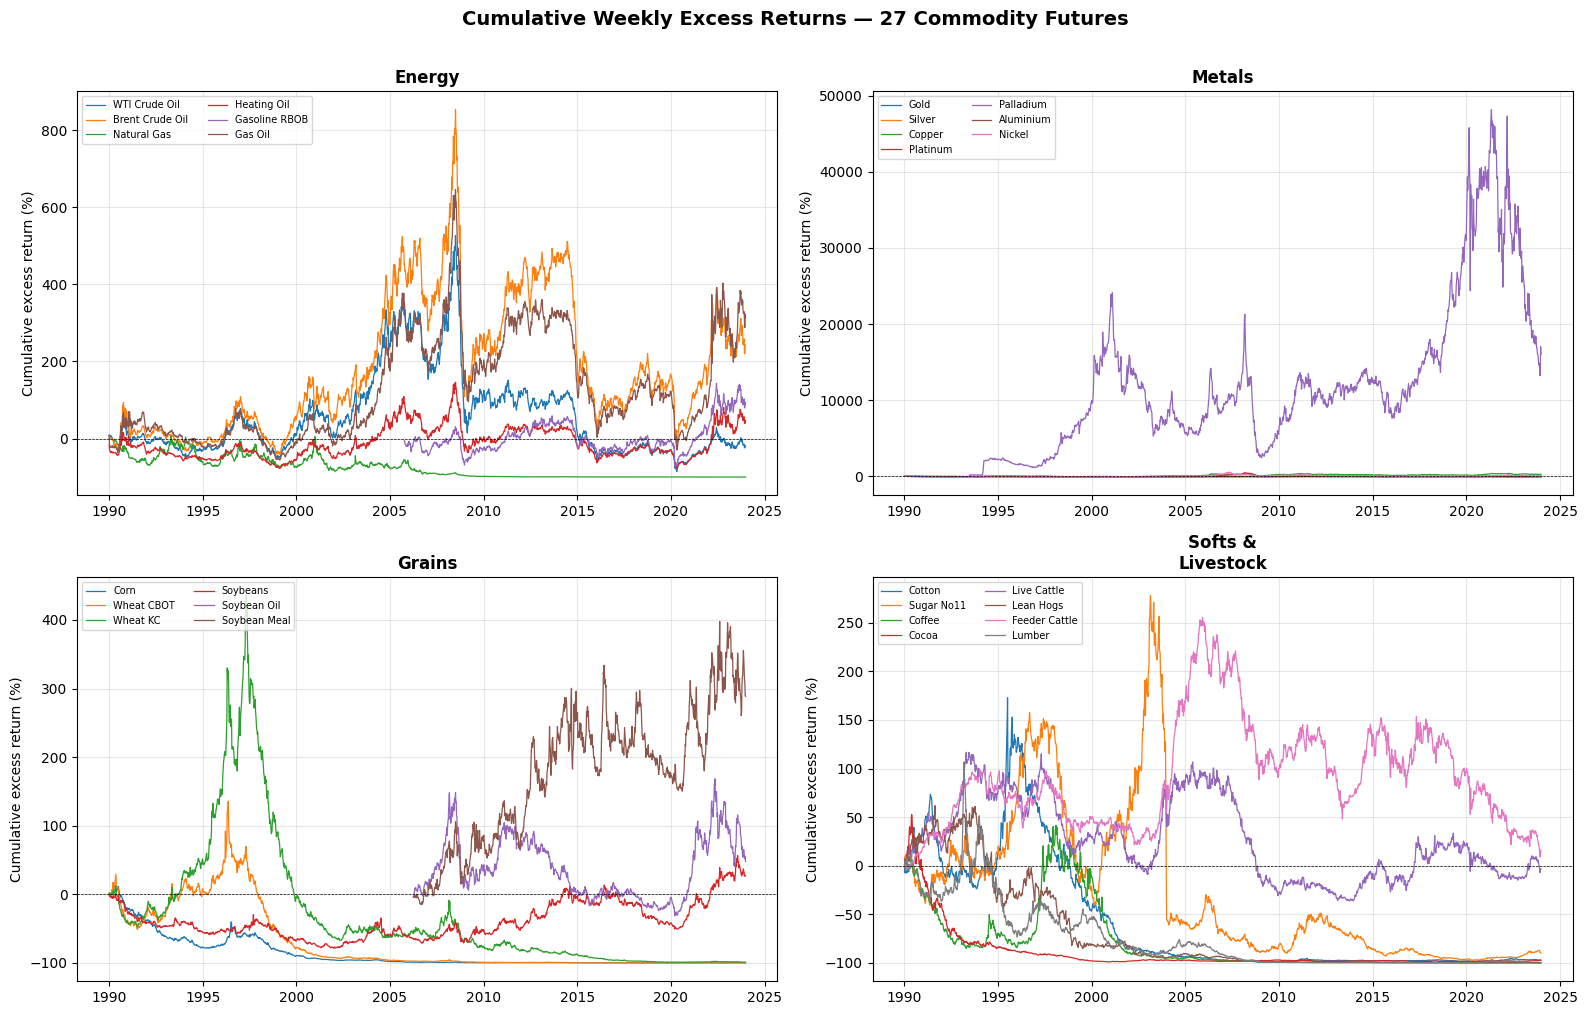

In [ ]:
# Plot cumulative excess returns by contract
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sectors = {
    'Energy'   : ['WTI Crude Oil', 'Brent Crude Oil', 'Natural Gas',
                  'Heating Oil', 'Gasoline RBOB', 'Gas Oil'],
    'Metals'   : ['Gold', 'Silver', 'Copper', 'Platinum', 'Palladium',
                  'Aluminium', 'Nickel'],
    'Grains'   : ['Corn', 'Wheat CBOT', 'Wheat KC', 'Soybeans',
                  'Soybean Oil', 'Soybean Meal'],
    'Softs &\nLivestock': ['Cotton', 'Sugar No11', 'Coffee', 'Cocoa',
                           'Live Cattle', 'Lean Hogs', 'Feeder Cattle', 'Lumber'],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (sector, contracts) in zip(axes, sectors.items()):
    for name in contracts:
        if name not in weekly_excess.columns:
            continue
        s = weekly_excess[name].dropna()
        cum = (1 + s).cumprod() - 1
        ax.plot(cum.index, cum * 100, linewidth=0.9, label=name)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(sector, fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative excess return (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Cumulative Weekly Excess Returns - 27 Commodity Futures',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10 · Save Outputs

In [ ]:
# ── Cell 10 (was 11): Save ────────────────────────────────────────────────────
import os

# commodity_returns_weekly.csv - individual contract returns (for currency nb)
weekly_excess.index.name = 'date'
weekly_excess.to_csv('Output/commodity_returns_weekly.csv')
print(f"Saved commodity_returns_weekly.csv  {weekly_excess.shape}")

# commodity_futures_weekly.csv - 12 portfolio returns
futures_weekly.index.name = 'date'
futures_weekly.to_csv('Output/commodity_futures_weekly.csv')
print(f"Saved commodity_futures_weekly.csv  {futures_weekly.shape}")

# commodity_factors_weekly.csv - 4 long-short factors
factors.index.name = 'date'
factors.to_csv('Output/commodity_factors_weekly.csv')
print(f"Saved commodity_factors_weekly.csv  {factors.shape}")

Saved commodity_returns_weekly.csv  (1774, 27)
Saved commodity_futures_weekly.csv  (1774, 12)
Saved commodity_factors_weekly.csv  (1774, 4)
